# Synthetic Parameter Recovery via pyVBMC

Validates the full inference pipeline end-to-end: generate synthetic data from **known** GP
parameters, then run the same pyVBMC machinery used on the real data (`model-study9-vbmc.ipynb`)
and check whether it recovers the true `(length_scale, mu_0)`.

This is the VBMC counterpart to `model-synthetic-recovery.ipynb` (which used a grid search).
It also tells us whether the boundary-hugging posterior on the real data is a pipeline problem
or just weak identifiability of this 15-test-feature design — if recovery works cleanly here,
the design identifies the parameters and the real-data behavior reflects the data, not a bug.

**Generative model** (matches the inference exactly):
1. Sample latent coherences `y = (y_test, y_train) ~ MVN(mu_0, K_θ)` at the true params.
2. Sample each training utterance `u_i ~ P(u | y_i)` (the speaker model).
3. For each test feature, `pz1_j = sigmoid(y_test_j)`; each participant draws
   `z ~ Bernoulli(pz1_j)` then a rating from `Beta(kl)` if z=1 else `Beta(nkl)`,
   rounded to the 0-100 slider grid.
Then recover `(length_scale, mu_0)` with pyVBMC, profiling the linking-function shapes per eval.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt
from scipy.special import logsumexp as scipy_logsumexp
from pyvbmc import VBMC

from model_jax import (
    rbf_kernel,
    p_u_given_y,
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
    beta_mixture_log_likelihood,
)

print(f"backend: {jax.default_backend()}")

backend: cpu


## Ground-truth parameters and feature geometry

True params are interior to the VBMC bounds (not on a boundary), so recovery is a fair test.
Feature embeddings are the real ones, so the spatial geometry — and hence how identifiable the
length scale is — matches the real experiment.

In [2]:
# Ground-truth parameters to recover
TRUE_PARAMS = {
    'length_scale': 0.4,
    'mu_0':         0.0,
    'output_scale': 1.5,
    'beta':         3.0,
}

with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)
train_df = df[df.split == 'train']
feat_idx = df.set_index('feature')

TEST_FEATURE_NAMES = [
    'can eat spicy food', 'eat breakfast very late', 'eat five meals a day',
    'like juice with pulp', 'put pepper on all their foods',
    'cry easily', 'like to collect rocks', 'like to dance',
    'like to give high-fives', 'like to read books',
    'can roll their tongue', 'can snap with their toes',
    'can wiggle their ears', 'have cold hands and feet', 'snore when they sleep',
]

x_train = jnp.array(train_df[['x_2d', 'y_2d']].values)   # (45, 2)
x_test  = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in TEST_FEATURE_NAMES]
)  # (15, 2)
n_train = x_train.shape[0]
J       = x_test.shape[0]
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")
print(f"True params: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']}")

x_train: (45, 2), x_test: (15, 2)
True params: ls=0.4, mu_0=0.0


## 1-2. Sample latent coherences and utterances

In [3]:
rng = np.random.default_rng(37)

# test first then train (matches make_log_density_fn_joint convention)
X_all = jnp.vstack([x_test, x_train])
mu    = jnp.full(J + n_train, TRUE_PARAMS['mu_0'])
K     = rbf_kernel(X_all, TRUE_PARAMS['length_scale'], TRUE_PARAMS['output_scale'])

y_all        = rng.multivariate_normal(np.array(mu), np.array(K))
y_test_true  = y_all[:J]
y_train_true = y_all[J:]
pz1_test_true = 1 / (1 + np.exp(-y_test_true))

# Sample each training utterance from the speaker: 0=generic, 1=specific
beta = TRUE_PARAMS['beta']
u_probs = np.array([float(p_u_given_y(0, float(y_i), beta)) for y_i in y_train_true])
u_train_true = (rng.uniform(size=n_train) > u_probs).astype(np.int32)
u_train      = jnp.array(u_train_true)

print(f"y_test range: [{y_test_true.min():.2f}, {y_test_true.max():.2f}]  "
      f"pz1_test range: [{pz1_test_true.min():.2f}, {pz1_test_true.max():.2f}]")
print(f"Utterances: {(u_train_true==0).sum()} generic, {(u_train_true==1).sum()} specific")
print(f"Realized y_test mean: {y_test_true.mean():.3f}  (true mu_0={TRUE_PARAMS['mu_0']}; "
      f"sampling scatter means recovered mu_0 may shift slightly)")

y_test range: [-2.29, 0.11]  pz1_test range: [0.09, 0.53]
Utterances: 15 generic, 30 specific
Realized y_test mean: -0.930  (true mu_0=0.0; sampling scatter means recovered mu_0 may shift slightly)


## 3. Sample ratings (discretized to the 0-100 slider grid)

Rounding to the slider grid matches the real data and lets the interval-likelihood fit compact
to unique values (fast). True linking-function shapes: kind-linked = high prevalence, not = low.

responses: (400, 15)


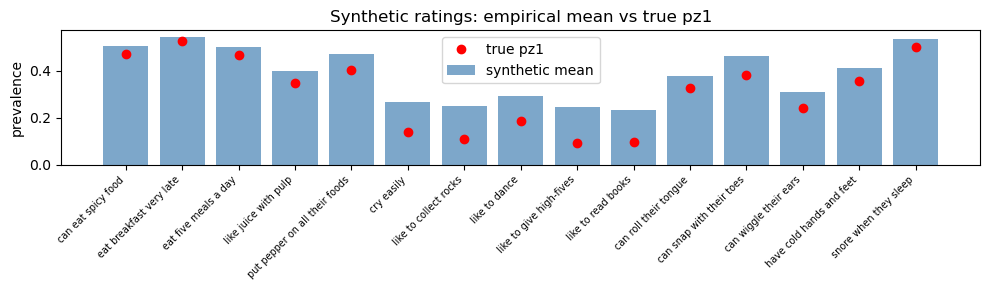

In [4]:
ALPHA_KL, BETA_KL   = 5.0, 1.0   # kind-linked component: high prevalence
ALPHA_NKL, BETA_NKL = 1.0, 5.0   # non-kind-linked: low prevalence
N_PARTICIPANTS = 400

ratings = np.zeros((N_PARTICIPANTS, J))
for j in range(J):
    z     = rng.uniform(size=N_PARTICIPANTS) < pz1_test_true[j]
    draws = np.where(z,
                     rng.beta(ALPHA_KL, BETA_KL, N_PARTICIPANTS),
                     rng.beta(ALPHA_NKL, BETA_NKL, N_PARTICIPANTS))
    ratings[:, j] = np.round(draws * 100) / 100   # discretize to slider grid
responses = jnp.array(ratings)
N = N_PARTICIPANTS
print(f"responses: {responses.shape}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(J), np.array(responses.mean(0)), color='steelblue', alpha=0.7, label='synthetic mean')
ax.plot(range(J), pz1_test_true, 'ro', label='true pz1')
ax.set_xticks(range(J)); ax.set_xticklabels(TEST_FEATURE_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('prevalence'); ax.set_title('Synthetic ratings: empirical mean vs true pz1')
ax.legend(); plt.tight_layout(); plt.show()

## Inference: pyVBMC over (length_scale, mu_0)

Identical `log_joint` to `model-study9-vbmc.ipynb`: per evaluation, run NUTS over the joint
coherences, fit the Beta-mixture shapes ONCE on the posterior-mean pz1, then score every thinned
draw under those fixed shapes (logsumexp). `output_scale` and `beta` are fixed at their true
values (as in the real run). Lighter MCMC than the real run since this is a pipeline check.

In [5]:
FIXED_PARAMS = {
    'output_scale': TRUE_PARAMS['output_scale'],
    'beta':         TRUE_PARAMS['beta'],
}

N_WARMUP   = 300
N_SAMPLES  = 1000
STEP       = 5      # thinning: 999 -> ~200 samples
MAX_EVALS  = 150    # VBMC budget knob (default noisy budget is 300; raise for a tighter posterior)

print(f"MCMC: {N_WARMUP} warmup, {N_SAMPLES} samples, thin {STEP} -> ~{(N_SAMPLES-1)//STEP} draws")

MCMC: 300 warmup, 1000 samples, thin 5 -> ~199 draws


In [6]:
eval_count = [0]
eval_log   = []   # [(phi, log_joint_val, noise_std), ...]

def log_joint(phi):
    """Log joint P(synthetic ratings, theta) for pyVBMC. phi = [log_ls, mu_0]."""
    log_ls, mu_0 = float(phi[0]), float(phi[1])
    length_scale = float(np.exp(log_ls))

    eval_count[0] += 1
    print(f"  eval {eval_count[0]:3d}: ls={length_scale:.3f}  mu_0={mu_0:.3f}", end="  ")

    # same priors as the real run
    log_prior_ls  = float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
    log_prior_mu0 = float(-0.5 * mu_0 ** 2)
    log_prior = log_prior_ls + log_prior_mu0

    params = {**FIXED_PARAMS, 'length_scale': length_scale, 'mu_0': mu_0}
    log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params)
    init_position = {'training_coherences': jnp.zeros(n_train), 'test_coherences': jnp.zeros(J)}

    rng_key = jax.random.PRNGKey(0)
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=N_WARMUP)
    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, N_SAMPLES)
    test_coherences_all = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences_all.append(np.array(state.position['test_coherences']))
    test_coherences_all = np.array(test_coherences_all)

    # fit linking-function shapes ONCE on the posterior-mean pz1; weight varies per draw
    pz1_draws   = np.array(jax.nn.sigmoid(test_coherences_all[::STEP]))     # (S, J)
    pz1_bar     = jnp.array(pz1_draws.mean(axis=0))
    beta_params = fit_beta_mixtures_all_features(responses, jnp.tile(pz1_bar, (N, 1)))
    log_liks_s  = [
        float(beta_mixture_log_likelihood(responses, jnp.array(pz1_draws[s]), beta_params))
        for s in range(pz1_draws.shape[0])
    ]

    log_lik   = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))
    noise_std = float(np.std(log_liks_s))
    if not np.isfinite(log_lik):
        log_lik, noise_std = -1e6, 1.0

    log_joint_val = float(log_lik + log_prior)
    print(f"log_lik={log_lik:.1f}  noise_std={noise_std:.2f}  log_joint={log_joint_val:.1f}")
    eval_log.append((np.array(phi, dtype=float), log_joint_val, noise_std))
    return log_joint_val, noise_std

In [7]:
# --- pyVBMC varG-squeeze patch (same bug fix as the real-data notebook) ---
import pyvbmc.vbmc.variational_optimization as _vopt
if not getattr(_vopt._gp_log_joint, "_varg_squeeze_patch", False):
    _orig_gp_log_joint = _vopt._gp_log_joint
    def _gp_log_joint_scalar_varg(*args, **kwargs):
        out = list(_orig_gp_log_joint(*args, **kwargs))
        if out[2] is not None:
            out[2] = float(np.squeeze(out[2]))
        return tuple(out)
    _gp_log_joint_scalar_varg._varg_squeeze_patch = True
    _vopt._gp_log_joint = _gp_log_joint_scalar_varg
    print("patched _gp_log_joint (varG squeeze)")

# Start AWAY from the truth so recovery is a real test (true ls=0.4, mu_0=0.0)
x0  = np.array([np.log(1.5), 1.0])
lb  = np.array([np.log(0.05), -4.0])
ub  = np.array([np.log(20.0),  4.0])
plb = np.array([np.log(0.1), -2.0])
pub = np.array([np.log(5.0),  2.0])
print(f"Start: ls={np.exp(x0[0]):.2f}, mu_0={x0[1]:.2f}  (true: ls=0.4, mu_0=0.0)")

vbmc = VBMC(log_joint, x0, lb, ub, plb, pub,
            options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS})
vbmc_result, vbmc_stats = vbmc.optimize()

patched _gp_log_joint (varG squeeze)
Start: ls=1.50, mu_0=1.00  (true: ls=0.4, mu_0=0.0)
Reshaping x0 to row vector.
Reshaping lower bounds to (1, 2).
Reshaping upper bounds to (1, 2).
Reshaping plausible lower bounds to (1, 2).
Reshaping plausible upper bounds to (1, 2).
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  eval   1: ls=1.500  mu_0=1.000  log_lik=-25900.1  noise_std=82.73  log_joint=-25900.9
  eval   2: ls=0.491  mu_0=1.705  log_lik=-25888.4  noise_std=1145.91  log_joint=-25889.9
  eval   3: ls=2.049  mu_0=-1.829  log_lik=-25923.3  noise_std=98.31  log_joint=-25925.4
  eval   4: ls=1.902  mu_0=-0.277  log_lik=-25928.1  noise_std=93.04  log_joint=-25928.5
  eval   5: ls=4.846  mu_0=-1.813  log_lik=-25941.9  noise_std=94.85  log_joint=-25944.7
  eval   6: ls=0.510  mu_0=0.511  log_lik=-25882.2  noise_std=309.74  log_joint=-25882.4
  eval   7: ls=0.360  m

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar subtract
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar multiply
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),


  eval  36: ls=19.964  mu_0=0.253  log_lik=-25960.0  noise_std=8.22  log_joint=-25963.0
  eval  37: ls=1.580  mu_0=0.616  log_lik=-25951.8  noise_std=23.59  log_joint=-25952.3
  eval  38: ls=19.960  mu_0=-0.033  log_lik=-25918.6  noise_std=16.81  log_joint=-25921.6
  eval  39: ls=19.947  mu_0=-0.426  log_lik=-25950.4  noise_std=5.18  log_joint=-25953.5
  eval  40: ls=18.255  mu_0=-0.037  log_lik=-25978.9  noise_std=7.01  log_joint=-25981.8
     6         40      -25945.56        48.36         8.39        2        217     
  eval  41: ls=16.109  mu_0=0.497  log_lik=-25976.4  noise_std=8.10  log_joint=-25979.2
  eval  42: ls=2.475  mu_0=1.037  log_lik=-25890.2  noise_std=119.95  log_joint=-25891.3
  eval  43: ls=16.446  mu_0=-1.094  log_lik=-25947.4  noise_std=19.56  log_joint=-25950.7
  eval  44: ls=1.644  mu_0=-1.066  log_lik=-25946.8  noise_std=97.72  log_joint=-25947.7
  eval  45: ls=16.330  mu_0=-0.387  log_lik=-26140.0  noise_std=59.53  log_joint=-26142.8
     7         45      -25

## Recovery results

Posterior over `(length_scale, mu_0)` vs the true values (red). Good recovery = the true point
sits inside the bulk of the posterior. Note `mu_0` may land slightly off 0 because the single GP
draw's realized mean differs from `mu_0` — that's expected sampling scatter, not a pipeline error.

param             true   post mean  post median                95% CI
length_scale     0.400      10.333       10.858   [0.275, 19.958]
mu_0             0.000      -1.179       -1.131   [-1.637, -1.102]

convergence: no  (evals: 150, ELBO: -25974.4)


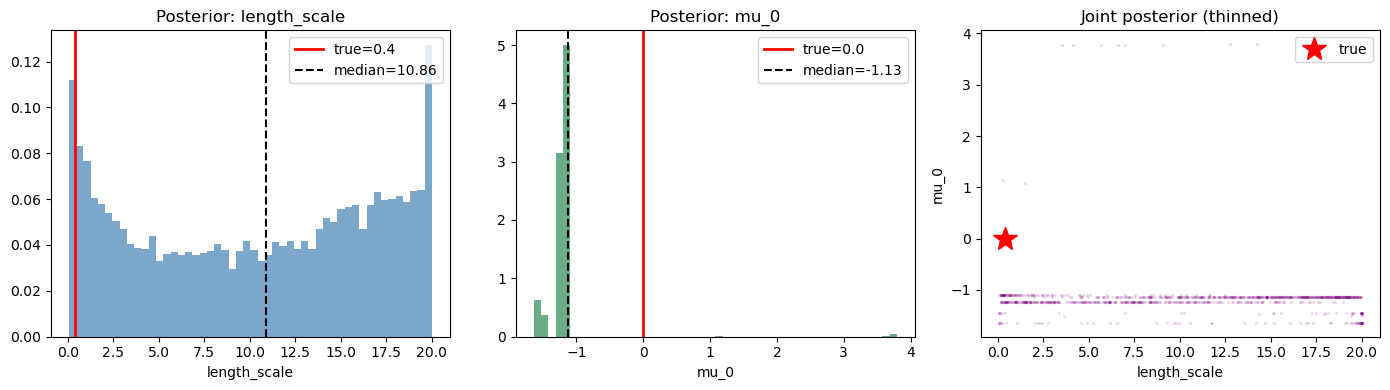

In [8]:
phi_samples, _ = vbmc_result.sample(int(1e4))
ls_samples  = np.exp(phi_samples[:, 0])
mu0_samples = phi_samples[:, 1]

ls_true, mu0_true = TRUE_PARAMS['length_scale'], TRUE_PARAMS['mu_0']
print(f"{'param':<14}{'true':>8}{'post mean':>12}{'post median':>13}{'95% CI':>22}")
print(f"{'length_scale':<14}{ls_true:>8.3f}{ls_samples.mean():>12.3f}{np.median(ls_samples):>13.3f}"
      f"   [{np.percentile(ls_samples,2.5):.3f}, {np.percentile(ls_samples,97.5):.3f}]")
print(f"{'mu_0':<14}{mu0_true:>8.3f}{mu0_samples.mean():>12.3f}{np.median(mu0_samples):>13.3f}"
      f"   [{np.percentile(mu0_samples,2.5):.3f}, {np.percentile(mu0_samples,97.5):.3f}]")
print(f"\nconvergence: {vbmc_stats['convergence_status']}  (evals: {vbmc_stats['func_count']}, "
      f"ELBO: {vbmc_stats['elbo']:.1f})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(ls_samples, bins=50, density=True, color='steelblue', alpha=0.7)
axes[0].axvline(ls_true, color='red', lw=2, label=f'true={ls_true}')
axes[0].axvline(np.median(ls_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(ls_samples):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Posterior: length_scale'); axes[0].legend()

axes[1].hist(mu0_samples, bins=50, density=True, color='seagreen', alpha=0.7)
axes[1].axvline(mu0_true, color='red', lw=2, label=f'true={mu0_true}')
axes[1].axvline(np.median(mu0_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(mu0_samples):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Posterior: mu_0'); axes[1].legend()

axes[2].scatter(ls_samples[::10], mu0_samples[::10], alpha=0.1, s=2, color='purple')
axes[2].plot(ls_true, mu0_true, 'r*', ms=18, label='true')
axes[2].set_xlabel('length_scale'); axes[2].set_ylabel('mu_0')
axes[2].set_title('Joint posterior (thinned)'); axes[2].legend()
plt.tight_layout(); plt.show()